# Day 011: Matrix-Matrix Multiplication (Combining transformations / Forward passes)


## 1. Objective
> To master matrix-matrix multiplication, evaluate the strict inner-dimension matching rules, and understand how this operation allows neural networks to process entire batches of data simultaneously (Batch Forward Passes) or combine multiple transformations into one.

## 2. Mathematical Foundation
> Matrix-matrix multiplication is not just a collection of dot products; it is the composition of linear transformations. When you multiply Matrix $A$ by Matrix $B$ to get Matrix $C$, you are computing the dot product of every row in $A$ against every column in $B$.  
>
> * **The Shape Rule:** To multiply $A$ by $B$, the number of columns in $A$ must equal the number of rows in $B$.   
> If $A \in \mathbb{R}^{m \times n}$ and $B \in \mathbb{R}^{n \times p}$, the resulting matrix $C$ will have shape $(m \times p)$.  
> * **The Core Operation:** Each element $C_{i,j}$ is the dot product of the $i$-th row of $A$ and the $j$-th column of $B$:  
> $$C_{i,j} = \sum_{k=1}^{n} A_{i,k} B_{k,j}$$
> * **Crucial Properties:**  
> * **Non-Commutative:** $AB \neq BA$. Order matters strictly.  
> * **Associative:** $(AB)C = A(BC)$. You can group multiplications differently without changing the result.  
> 
> ### Visualization 1: The Shape Matching Rule
```text
   Matrix (A)         Matrix (B)           Output (C)
    (m × n)      @     (n × p)      =       (m × p)
         │              │
         └──────────────┘
         Inner dimensions 
           must match!

Visualization 2: Row by column computation
MATRIX A               MATRIX B                   MATRIX C (A @ B)
                                                    
  [ A11   A12 ]          [ B11   B12 ]         [ (A11·B11 + A12·B21)   (A11·B12 + A12·B22) ]
  [ A21   A22 ]    @     [ B21   B22 ]    =    [ (A21·B11 + A22·B21)   (A21·B12 + A22·B22) ]
  [ A31   A32 ]                                [ (A31·B11 + A32·B21)   (A31·B12 + A32·B22) ]
                                                                       
    (3 × 2)                (2 × 2)                     (3 × 2)

## 3. Real-World & AI Applications
> **Business Logic (Batch Processing):** Imagine a retail company with 3 stores. Matrix $A$ ($3 \times 4$) represents the inventory of 4 different products at each store. Matrix $B$ ($4 \times 2$) represents 2 different pricing models (e.g., Wholesale vs. Retail) for those 4 products. Computing $AB$ instantly yields a $3 \times 2$ matrix showing the total Wholesale and Retail value for each of the 3 stores.AI/ML Use Case (Batch Forward Pass): In deep learning, passing one image through a network at a time is highly inefficient. Instead, we pass a batch of images. If weight matrix $W$ is $(128 \times 784)$ (128 neurons, 784 pixels), and input matrix $X$ is $(784 \times 32)$ (a batch of 32 images), $WX$ yields a $(128 \times 32)$ output matrix. You just computed the 128 neuron activations for 32 different images in a single mathematical step.
>
> **AI/ML Use Case (Batch Forward Pass):** In deep learning, passing one image through a network at a time is highly inefficient. Instead, we pass a batch of images. If weight matrix $W$ is $(128 \times 784)$ (128 neurons, 784 pixels), and input matrix $X$ is $(784 \times 32)$ (a batch of 32 images), $WX$ yields a $(128 \times 32)$ output matrix. You just computed the 128 neuron activations for 32 different images in a single mathematical step.

## 4. Algorithmic Strategy
>- **Dimension Alignment**: Always verify `A.shape[1] == B.shape[0]`.  
>- **The @ Operator**: Use Python's native matrix multiplication operator `@` or `np.matmul()`.  
>- **Avoid** * : The `*` operator performs element-wise multiplication **(Hadamard product)**, which is entirely different and requires the matrices to be the exact same shape.

## 5. Implementation

In [1]:
import numpy as np

# --- 1. Define Matrices ---
# Matrix A: 3 stores, 4 products -> Shape: (3, 4)
A = np.array([[ 10,  5,  2,  1],
              [  8,  6,  1,  2],
              [ 12,  4,  3,  0]])

# Matrix B: 4 products, 2 pricing models (Wholesale, Retail) -> Shape: (4, 2)
B = np.array([[ 2.0,  3.0],
              [ 1.5,  2.5],
              [ 5.0,  7.0],
              [ 4.0,  5.0]])

# --- 2. The Matrix Multiplication (A @ B) ---
C = A @ B  

print("--- Matrix-Matrix Multiplication ---")
print(f"Matrix A shape: {A.shape}")
print(f"Matrix B shape: {B.shape}")
print(f"Result C shape: {C.shape}\n")

print("Result Matrix C (Total Values per store per pricing model):")
print(C)
print("\n")


--- Matrix-Matrix Multiplication ---
Matrix A shape: (3, 4)
Matrix B shape: (4, 2)
Result C shape: (3, 2)

Result Matrix C (Total Values per store per pricing model):
[[41.5 61.5]
 [38.  56. ]
 [45.  67. ]]




## 6. Verification

In [ ]:
import time
# Simulate a real ML Batch Forward Pass: 
# 128 neurons processing 784 features for a batch of 64 inputs.
W_layer = np.random.randn(128, 784)  # Shape: (m, n)
X_batch = np.random.randn(784, 64)   # Shape: (n, p)

print("--- Performance Verification ---")
print(f"Weight Matrix (W) shape: {W_layer.shape}")
print(f"Batch Input (X) shape:   {X_batch.shape}\n")

# --- Test 1: Manual Nested Math (3 loops!) ---
start_time = time.time()

# Output shape will be (128, 64)
manual_output = np.zeros((W_layer.shape[0], X_batch.shape[1]))

# O(m * p * n) operations
for i in range(W_layer.shape[0]):          # Loop through rows of W (m)
    for j in range(X_batch.shape[1]):      # Loop through columns of X (p)
        dot_product = 0
        for k in range(W_layer.shape[1]):  # Loop through inner dimension (n)
            dot_product += W_layer[i, k] * X_batch[k, j]
        manual_output[i, j] = dot_product
    
manual_time = time.time() - start_time
print(f"Manual Python Loops Time: {manual_time:.4f} seconds")

# --- Test 2: NumPy Vectorization ---
start_time = time.time()
vectorized_output = W_layer @ X_batch
vectorized_time = time.time() - start_time
print(f"NumPy '@' Operator Time:  {vectorized_time:.6f} seconds")

speedup = manual_time / vectorized_time
print(f"\n🚀 Vectorized Matrix Math is {speedup:.1f} times faster!")
print(f"Mathematical equivalence: {np.allclose(manual_output, vectorized_output)}")


### Visualization with Matplotlib

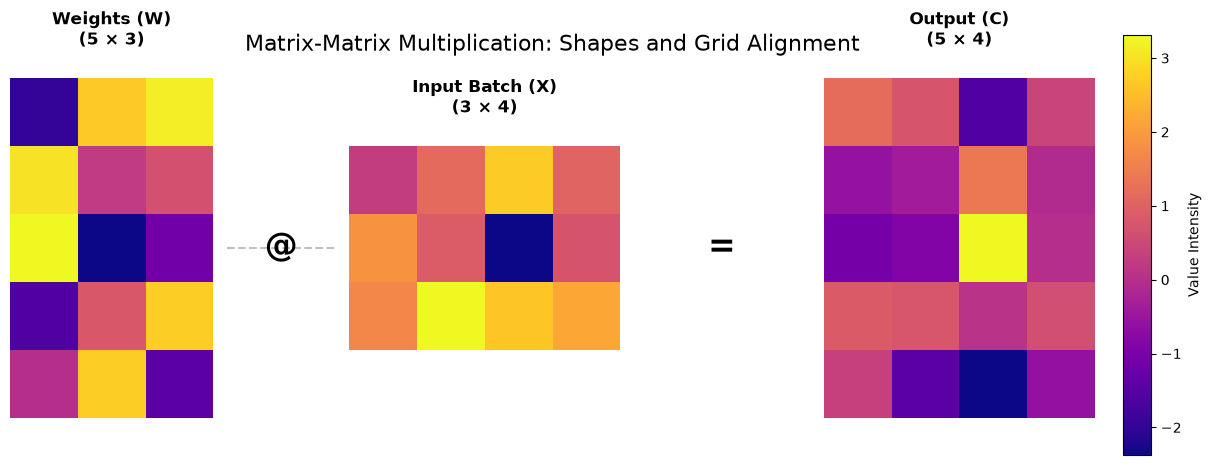

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# Data Setup for Heatmap Visualization
# ==========================================

# Let's map a small conceptual neural network layer processing a batch
# W = Weight Matrix (5 neurons, 3 features) -> Shape (5, 3)
# X = Input Batch (3 features, 4 examples)  -> Shape (3, 4)
W_vis = np.random.randn(5, 3) 
X_vis = np.random.randn(3, 4) 

# C = Output Activations -> Shape (5, 4)
C_vis = W_vis @ X_vis 

# ==========================================
# Plotting
# ==========================================

fig, ax = plt.subplots(1, 1, figsize=(14, 6))
ax.set_title("Matrix-Matrix Multiplication: Shapes and Grid Alignment", fontsize=16, pad=20)
ax.axis('off')

# Plot Weight Matrix (A)
im_w = ax.imshow(W_vis, extent=[0, 3, 0, 5], cmap='plasma')
ax.text(1.5, 5.5, 'Weights (W)\n(5 × 3)', ha='center', fontsize=12, weight='bold')

# Math symbol
ax.text(4, 2.5, '@', ha='center', va='center', fontsize=24, weight='bold')

# Plot Input Batch Matrix (B)
im_x = ax.imshow(X_vis, extent=[5, 9, 1, 4], cmap='plasma')
ax.text(7, 4.5, 'Input Batch (X)\n(3 × 4)', ha='center', fontsize=12, weight='bold')

# Math symbol
ax.text(10.5, 2.5, '=', ha='center', va='center', fontsize=24, weight='bold')

# Plot Output Matrix (C)
im_c = ax.imshow(C_vis, extent=[12, 16, 0, 5], cmap='plasma')
ax.text(14, 5.5, 'Output (C)\n(5 × 4)', ha='center', fontsize=12, weight='bold')

# Add visual guides (lines showing the inner dimensions match)
ax.plot([3.2, 4.8], [2.5, 2.5], color='grey', linestyle='--', alpha=0.5)

# Add colorbar for reference
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(im_c, cax=cbar_ax, label='Value Intensity')

plt.subplots_adjust(wspace=0.4)
plt.show()

## 7. Complexity Analysis
> - **Time Complexity:** $\mathcal{O}(m \cdot n \cdot p)$. To compute an $(m \times p)$ output matrix, there are $m \cdot p$ elements to calculate. Each element requires a dot product of a vector of length $n$, meaning $n$ multiplications and additions.  
> - **Space Complexity:** $\mathcal{O}(m \cdot p)$. The resulting output matrix requires a new array of dimensions $m \times p$ to store the computed values.
